In [3]:
!pip install mlxtend


Explained Variance Ratio:
 [0.72962445 0.22850762 0.03668922 0.00517871]


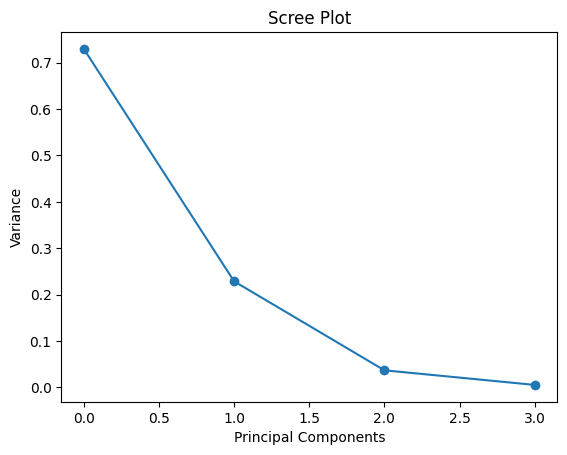

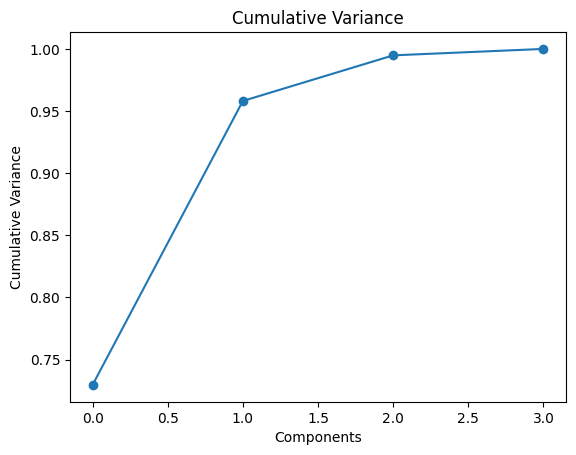

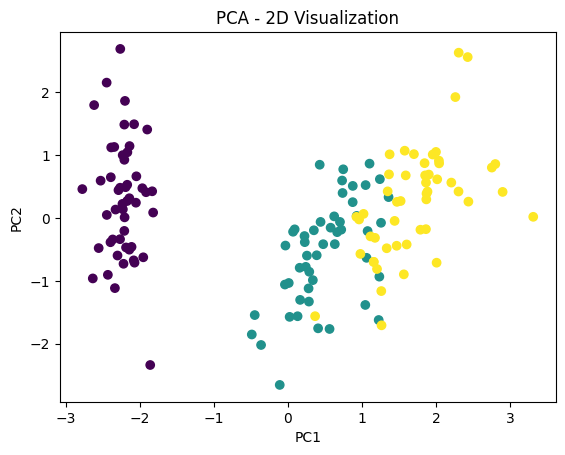

In [4]:
# Roll No: 24BAD077
# Name: Navithanjali M S

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -------------------------------
# Step 1: Load Dataset
# -------------------------------

data = load_iris()
X = data.data
y = data.target

# -------------------------------
# Step 2: Standardization
# -------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# Step 3: Apply PCA
# -------------------------------

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# -------------------------------
# Step 4: Explained Variance
# -------------------------------

print("\nExplained Variance Ratio:\n", pca.explained_variance_ratio_)

# -------------------------------
# Step 5: Scree Plot
# -------------------------------

plt.figure()
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Components")
plt.ylabel("Variance")
plt.show()

# -------------------------------
# Step 6: Cumulative Variance
# -------------------------------

cum_var = pca.explained_variance_ratio_.cumsum()
plt.figure()
plt.plot(cum_var, marker='o')
plt.title("Cumulative Variance")
plt.xlabel("Components")
plt.ylabel("Cumulative Variance")
plt.show()

# -------------------------------
# Step 7: Reduce to 2D
# -------------------------------

pca2 = PCA(n_components=2)
X_reduced = pca2.fit_transform(X_scaled)

# -------------------------------
# Step 8: 2D Scatter Plot
# -------------------------------

plt.figure()
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - 2D Visualization")
plt.show()

Transactions:
 [['milk', 'bread', 'butter'], ['beer', 'bread'], ['milk', 'bread', 'beer', 'butter'], ['bread', 'butter'], ['milk', 'bread', 'beer']]

One-Hot Encoded Data:

    beer  bread  butter   milk
0  False   True    True   True
1   True   True   False  False
2   True   True    True   True
3  False   True    True  False
4   True   True   False   True

Frequent Itemsets:

    support               itemsets
0       0.6                 (beer)
1       1.0                (bread)
2       0.6               (butter)
3       0.6                 (milk)
4       0.6          (bread, beer)
5       0.4           (beer, milk)
6       0.6        (bread, butter)
7       0.6          (bread, milk)
8       0.4         (milk, butter)
9       0.4    (bread, beer, milk)
10      0.4  (bread, milk, butter)

Association Rules:

        antecedents      consequents  support  confidence      lift
0           (bread)           (beer)      0.6    0.600000  1.000000
1            (beer)          (bread)      0

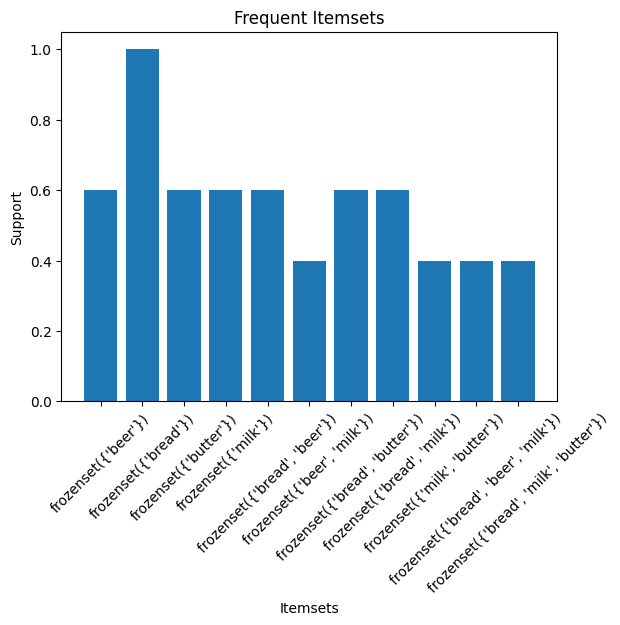

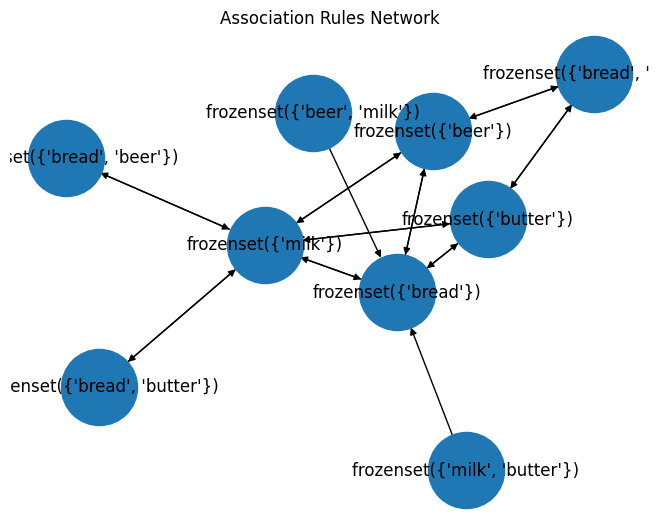

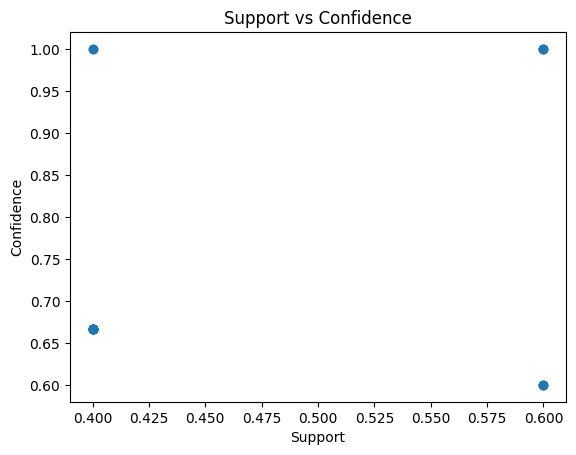

In [5]:
# -------------------------------
# Import Libraries
# -------------------------------
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import networkx as nx

# -------------------------------
# Step 1: Load Dataset
# -------------------------------

# Sample transaction dataset (you can replace with CSV if needed)
transactions = [
    ['milk', 'bread', 'butter'],
    ['beer', 'bread'],
    ['milk', 'bread', 'beer', 'butter'],
    ['bread', 'butter'],
    ['milk', 'bread', 'beer'],
]

print("Transactions:\n", transactions)

# -------------------------------
# Step 2: One-Hot Encoding
# -------------------------------

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_array, columns=te.columns_)

print("\nOne-Hot Encoded Data:\n")
print(df)

# -------------------------------
# Step 3: Generate Frequent Itemsets
# -------------------------------

frequent_itemsets = apriori(df, min_support=0.4, use_colnames=True)

print("\nFrequent Itemsets:\n")
print(frequent_itemsets)

# -------------------------------
# Step 4: Generate Association Rules
# -------------------------------

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)

print("\nAssociation Rules:\n")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

# -------------------------------
# Step 5: Visualization
# -------------------------------

# Bar Chart of Frequent Itemsets
frequent_itemsets['itemsets'] = frequent_itemsets['itemsets'].astype(str)

plt.figure()
plt.bar(frequent_itemsets['itemsets'], frequent_itemsets['support'])
plt.xlabel("Itemsets")
plt.ylabel("Support")
plt.title("Frequent Itemsets")
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# Step 6: Network Graph
# -------------------------------

G = nx.DiGraph()

for _, row in rules.iterrows():
    G.add_edge(str(row['antecedents']), str(row['consequents']), weight=row['confidence'])

pos = nx.spring_layout(G)

plt.figure()
nx.draw(G, pos, with_labels=True, node_size=3000)
plt.title("Association Rules Network")
plt.show()

# -------------------------------
# Step 7: Support vs Confidence
# -------------------------------

plt.figure()
plt.scatter(rules['support'], rules['confidence'])
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")
plt.show()